# Детекция изображений животных

## 1. Скачивание необходимых библиотек

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import shutil
from ultralytics import YOLO

## 2. Загрузка предобученной модели YOLO v8

In [39]:
model = YOLO('yolov8n.pt')

## 3. Загрузка и предобработка изображения

In [40]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Path to dataset files: /Users/mishafoniakov/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2


In [41]:
image_example = os.path.join(path, 'raw-img', 'elefante', 'e83db30d2cfd033ed1584d05fb1d4e9fe777ead218ac104497f5c978a4efb4bb_640.jpg') # Загрузка изображения
image = cv2.imread(image_example) # Предобработка изображения
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Преобазование изображение из BGR в RGB 

## 4. Применение модели

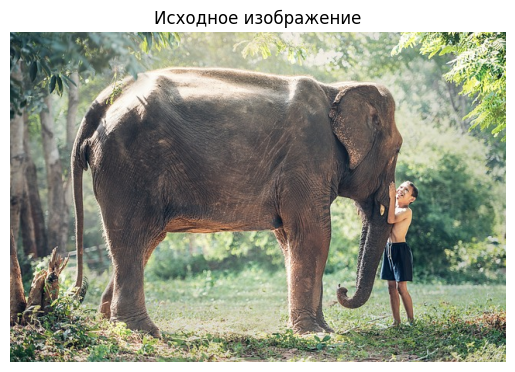

In [42]:
# Отображение исходного изображения
plt.imshow(image_rgb)
plt.title("Исходное изображение")
plt.axis("off")
plt.show()

In [43]:
# Применение модели YOLOv8
results = model(image_example)[0]


image 1/1 /Users/mishafoniakov/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2/raw-img/elefante/e83db30d2cfd033ed1584d05fb1d4e9fe777ead218ac104497f5c978a4efb4bb_640.jpg: 448x640 2 persons, 1 elephant, 65.0ms
Speed: 1.4ms preprocess, 65.0ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


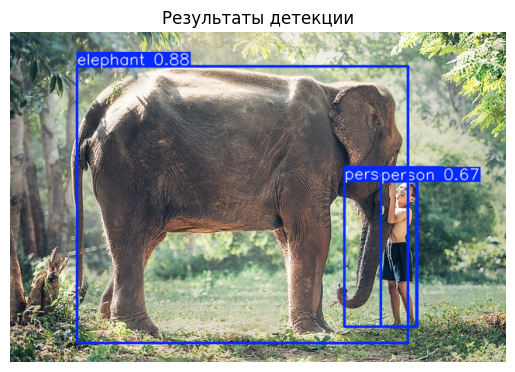

In [44]:
annotated_image = results.plot() # Используем метод .plot() для визуализации результатов
annotated_image_rgb = cv2.cvtColor(np.array(annotated_image), cv2.COLOR_BGR2RGB) # Преобразование массива NumPy обратно в RGB формат для отображения в Matplotlib
plt.imshow(annotated_image_rgb)  # Отображение изображения с результатами
plt.title("Результаты детекции")
plt.axis("off")
plt.show()

## 5. Подсчёт количества обнаруженных объектов

In [45]:
detected_objects = results.boxes.cls  # Определяем классы объектов
unique_classes, counts = np.unique(detected_objects.cpu().numpy(), return_counts=True) # Определяем количество объектов по классам
for cls, count in zip(unique_classes, counts):
    print(f"Класс - {int(cls)}, название - {results.names.get(int(cls))}: {count} объектов")
total_animals = sum(counts) # Вывод общего количества обнаруженных животных (всех классов)
print(f"Общее количество обнаруженных животных: {total_animals}")

Класс - 0, название - person: 2 объектов
Класс - 20, название - elephant: 1 объектов
Общее количество обнаруженных животных: 3


## 6. Функция по созданию детекции изображений

In [46]:
class ImageDetectionYOLO:

    def __init__(self, model, image):
        self.model = model
        self.image = image
    
    def image_preparation(self):
        img = cv2.imread(self.image)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img_rgb
    
    def modeling(self, img):
        results = self.model(img)[0]
        imgr = results.plot()
        imgr = cv2.cvtColor(np.array(imgr), cv2.COLOR_BGR2RGB)
        return imgr
    
    def __call__(self):
        img = self.image_preparation()
        imgr = self.modeling(img)
        plt.imshow(imgr)  # Отображение изображения с результатами
        plt.title("Результаты детекции")
        plt.axis("off")
        plt.show()
        

## 7. Работа функции

/Users/mishafoniakov/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2/raw-img/elefante

0: 480x640 2 elephants, 75.6ms
Speed: 3.7ms preprocess, 75.6ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


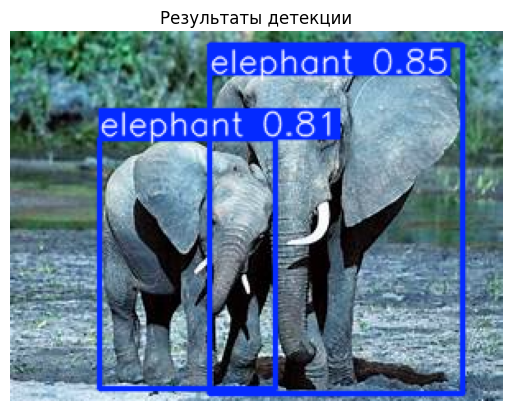


0: 640x480 1 elephant, 71.8ms
Speed: 1.9ms preprocess, 71.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)


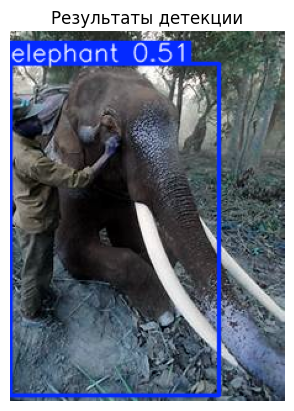


0: 320x640 1 dog, 1 bear, 52.1ms
Speed: 1.2ms preprocess, 52.1ms inference, 0.8ms postprocess per image at shape (1, 3, 320, 640)


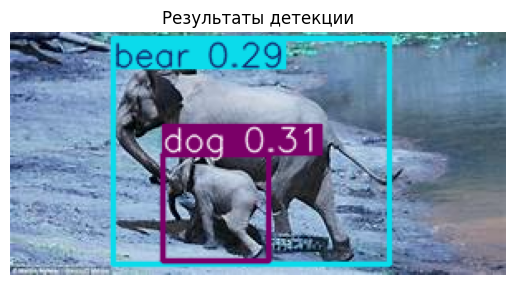


0: 448x640 2 elephants, 67.1ms
Speed: 1.3ms preprocess, 67.1ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)


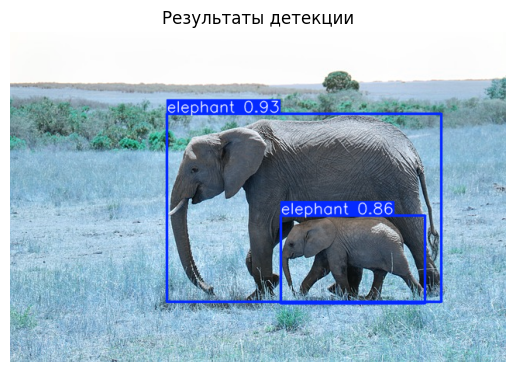


0: 640x448 3 elephants, 62.1ms
Speed: 1.6ms preprocess, 62.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 448)


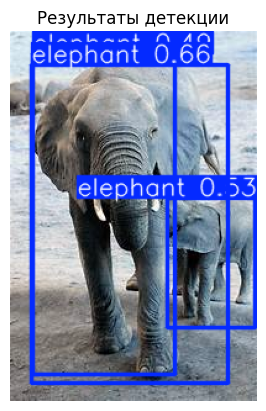


0: 448x640 1 sheep, 2 elephants, 72.4ms
Speed: 1.9ms preprocess, 72.4ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)


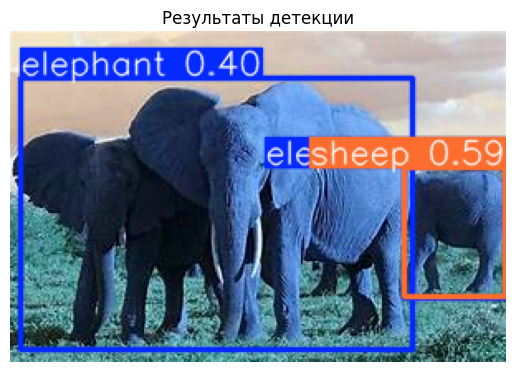


0: 640x640 1 elephant, 100.8ms
Speed: 2.7ms preprocess, 100.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


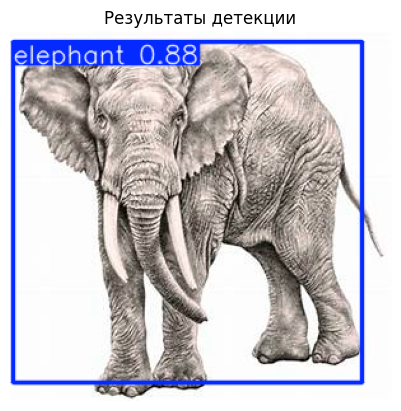


0: 352x640 2 persons, 1 cow, 1 elephant, 103.0ms
Speed: 1.2ms preprocess, 103.0ms inference, 1.5ms postprocess per image at shape (1, 3, 352, 640)


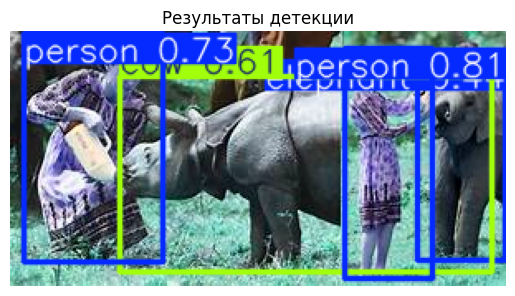


0: 448x640 1 elephant, 101.2ms
Speed: 2.1ms preprocess, 101.2ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)


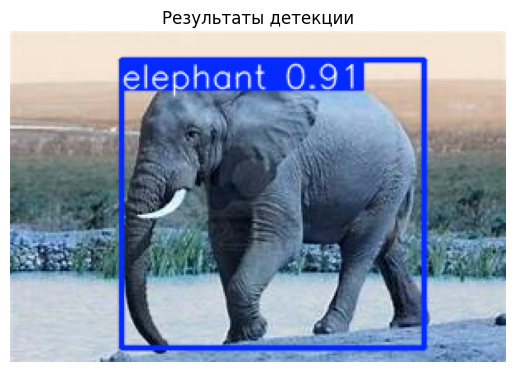


0: 480x640 3 elephants, 74.8ms
Speed: 1.1ms preprocess, 74.8ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)


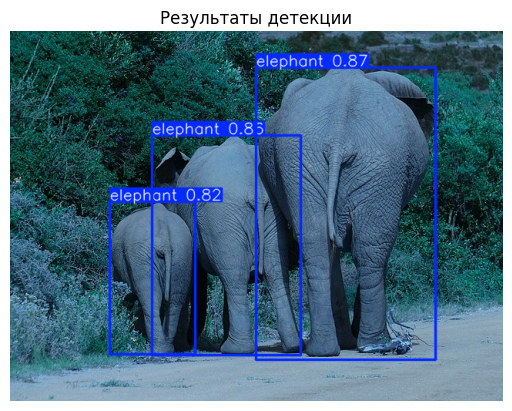

In [47]:
model = YOLO('yolov8n.pt')
path = os.path.join(path, 'raw-img', 'elefante')
print(path)
for img in os.listdir(path)[:10]:
    mod = ImageDetectionYOLO(model, os.path.join(path, img))
    mod()